# Business Insights & Retention Analysis

## About this notebook
This notebook analyses the RFM segments produced in notebook 2 to extract
actionable business insights. Each segment is profiled by behaviour and revenue
contribution, and targeted retention strategies are recommended for each group.

Steps covered:
1. Segment size and distribution analysis
2. Segment-wise RFM behaviour profiling
3. Revenue contribution by segment
4. Visualisations
5. Retention strategy recommendations per segment

In [19]:
import pandas as pd

rfm_df = pd.read_csv("../data/rfm_data.csv")
rfm_df.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_total,Segment
0,12346,2011-01-18 10:01:00,326,1,77183.60,1,1,5,115,7,Lost
1,12347,2011-12-07 15:52:00,2,7,4310.00,5,5,5,555,15,Champions
2,12348,2011-09-25 13:13:00,75,4,1797.24,2,4,4,244,10,At Risk
3,12349,2011-11-21 09:51:00,19,1,1757.55,4,1,4,414,9,Promising
4,12350,2011-02-02 16:01:00,310,1,334.40,1,1,2,112,4,Lost


In [20]:
#segment distribution (percentage)
rfm_df['Segment'].value_counts(normalize=True)*100

Segment
Champions          26.256339
Lost               24.550484
Loyal Customers    18.925772
At Risk            14.822499
Needs Attention     8.091286
Promising           7.353619
Name: proportion, dtype: float64

### Insight - Segment Distribution
The largest segment is **Potential Loyalists / Needs Attention**, suggesting most customers
have shown some engagement but haven't yet converted to loyal behaviour. Champions are a
small but critical group — protecting their retention should be top priority.

In [21]:
#segment wise metrics 
rfm_df.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,152.844479,3.404355,1244.994636
Champions,13.311677,9.986831,5204.323012
Lost,217.897653,1.101408,487.707579
Loyal Customers,38.043849,3.643118,1651.333386
Needs Attention,53.504274,1.162393,461.061510
Promising,18.517241,1.241379,458.202414


### Insight - Segment Behaviour Profile
Champions have the lowest Recency (bought most recently), highest Frequency,
and highest Monetary value - confirming they are the most engaged customers.
The Lost segment shows very high Recency (haven't purchased in a long time)
and low Frequency, meaning re-engagement campaigns for this group will have
a low success rate and may not be worth the cost.

In [22]:
#revenue contribution by segment
rfm_df.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

Segment
Champions          5927723.911
Loyal Customers    1355744.710
At Risk             800531.551
Lost                519408.572
Needs Attention     161832.590
Promising           146166.570
Name: Monetary, dtype: float64

Visualizations

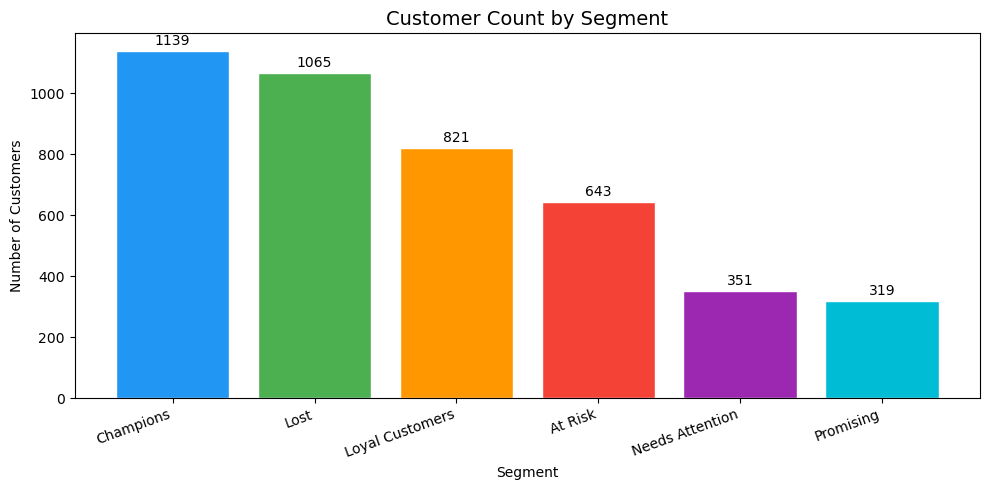

In [23]:
#segment size
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

segment_counts = rfm_df['Segment'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(segment_counts.index, segment_counts.values,
               color=['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#00BCD4'],
               edgecolor='white')

for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontsize=10)

plt.title('Customer Count by Segment', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

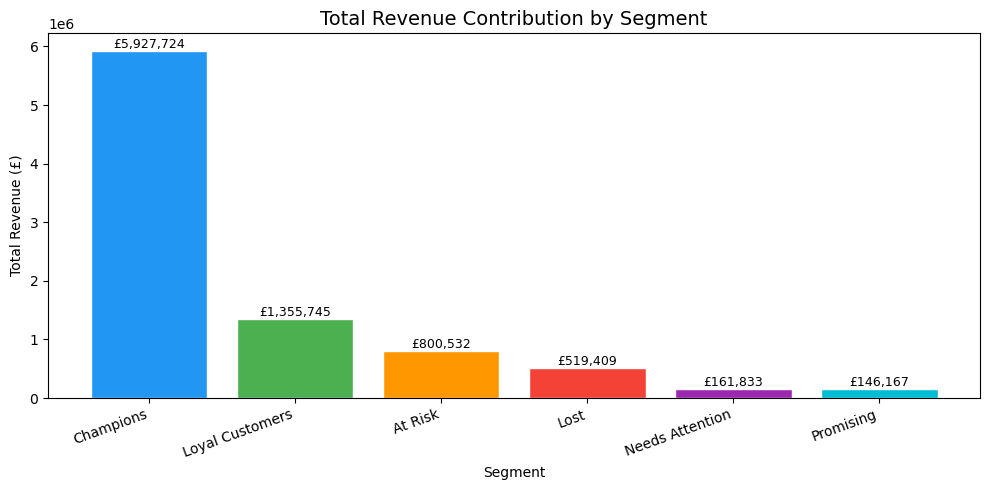

In [24]:
# revenue by segment
revenue_by_segment = rfm_df.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(revenue_by_segment.index, revenue_by_segment.values,
               color=['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#00BCD4'],
               edgecolor='white')

for bar, val in zip(bars, revenue_by_segment.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'£{val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.title('Total Revenue Contribution by Segment', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Insight - Revenue Concentration
A small group of Champions drives a disproportionately large share of total revenue -
a classic Pareto pattern. This means **losing even a few Champions has an outsized
impact on the business** compared to losing customers from any other segment.

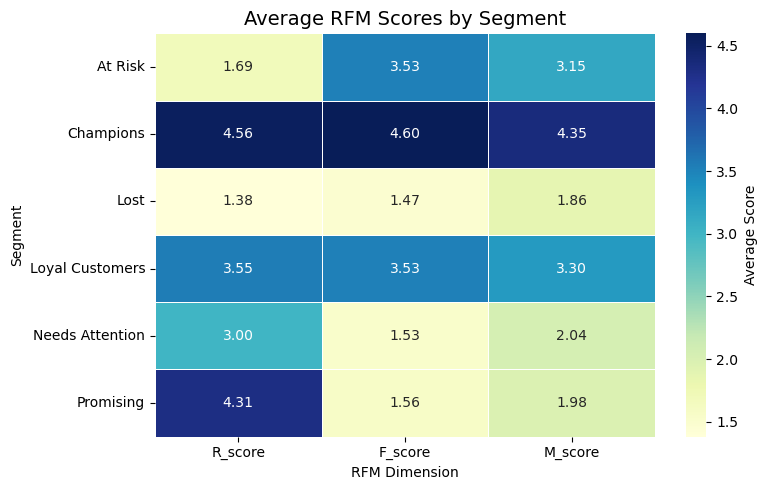

In [25]:
# rfm heatmap by segment
import seaborn as sns

segment_profile = rfm_df.groupby('Segment')[['R_score','F_score','M_score']].mean().round(2)

plt.figure(figsize=(8, 5))
sns.heatmap(segment_profile, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Average Score'})
plt.title('Average RFM Scores by Segment', fontsize=14)
plt.xlabel('RFM Dimension')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

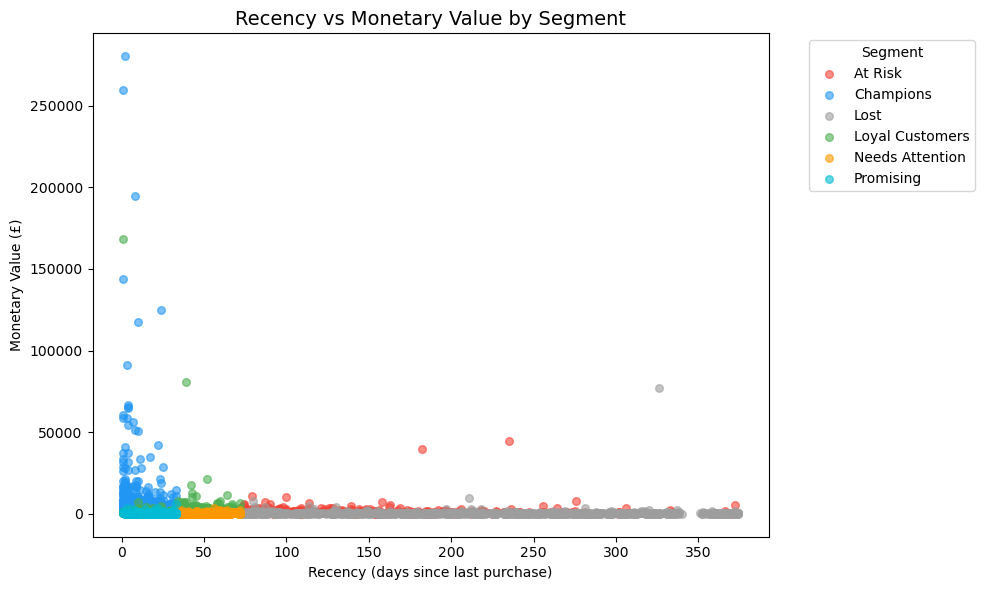

In [26]:
# Recency vs Monetary Scatter Plot
colors = {
    'Champions': '#2196F3',
    'Loyal Customers': '#4CAF50',
    'Promising': '#00BCD4',
    'Needs Attention': '#FF9800',
    'At Risk': '#F44336',
    'Lost': '#9E9E9E'
}

plt.figure(figsize=(10, 6))
for segment, group in rfm_df.groupby('Segment'):
    plt.scatter(group['Recency'], group['Monetary'],
                label=segment, alpha=0.6, s=30,
                color=colors.get(segment, 'gray'))

plt.title('Recency vs Monetary Value by Segment', fontsize=14)
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary Value (£)')
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

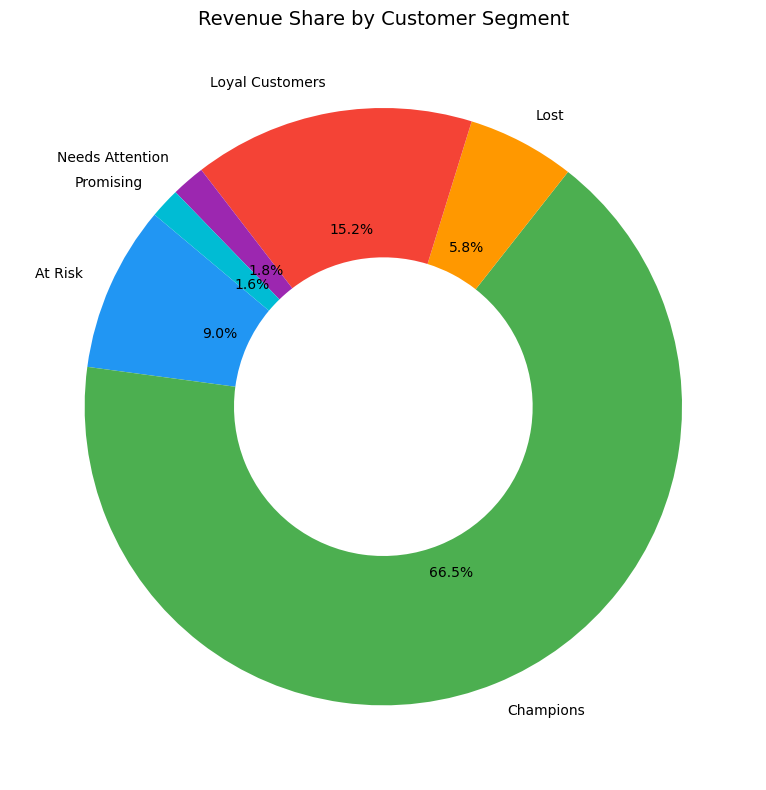

In [27]:
# Revenue Percentage 
revenue_pct = rfm_df.groupby('Segment')['Monetary'].sum()

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    revenue_pct,
    labels=revenue_pct.index,
    autopct='%1.1f%%',
    colors=['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#00BCD4'],
    startangle=140,
    wedgeprops=dict(width=0.5)   # makes it a donut
)
plt.title('Revenue Share by Customer Segment', fontsize=14)
plt.tight_layout()
plt.show()

## Retention Strategy Recommendations

| Segment | Behaviour Profile | Recommended Strategy |
|---|---|---|
| Champions | Recent, frequent, high spend | Loyalty rewards, early access to new products, ask for reviews |
| Loyal Customers | Frequent buyers, moderate recency | Upsell higher-value products, referral programme |
| Promising | Recent but low frequency | Welcome series, first repeat purchase discount |
| Needs Attention | Average across all dimensions | Re-engagement email, personalised product recommendations |
| At Risk | Used to buy often but gone quiet | Win-back campaign, "We miss you" discount offer |
| Lost | Not bought in a long time, low frequency | Last-chance offer or deprioritise — low ROI to re-engage |

### Key Business Takeaways
1. **Protect Champions** — they are few but drive the most revenue
2. **Convert Promising customers** — they are recent and reachable, highest conversion potential
3. **Act fast on At Risk** — they were once valuable and can still be recovered
4. **Don't overspend on Lost** — re-engagement ROI is low for this segment